In [1]:
import numpy as np
import pandas as pd
import cobra
from cobra.io import read_sbml_model
import matplotlib.pyplot as plt
import seaborn as sns
from cobra import Model, Reaction, Metabolite
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import random
from scipy.stats import mannwhitneyu, kruskal
from sklearn.preprocessing import normalize, LabelEncoder, MinMaxScaler

In [2]:
#import early exponential CHO model (iCHO2441 with transcriptomics integrated): https://doi.org/10.1002/bit.28982
%store -r constrained_4
model = constrained_4

#### Figure 1a

In [3]:
#generate a dataframe of random objective functions
reaction_ids = []
for r in model.reactions:
    reaction_ids.append(r.id)

growth = model.reactions.get_by_id('biomass_cho_prod')
igg = model.reactions.get_by_id('ICproduct_TRANSLATION_protein')
glucose = model.reactions.get_by_id('EX_glc(e)')
glutamine = model.reactions.get_by_id('EX_gln_L(e)')
ammonia = model.reactions.get_by_id('EX_nh4(e)')
lactate = model.reactions.get_by_id('EX_lac_L(e)')

flux_df = pd.DataFrame()
flux_df['reaction_ids'] = reaction_ids
flux_df = flux_df.set_index('reaction_ids')

labels = ["growth", "igg", "glucose", "glutamine", "ammonia", "lactate"]

for i in range(500):
    coefficients = [random.uniform(-1, 1) for _ in range(6)]
    abs_sum = sum(abs(c) for c in coefficients)
    coefficients = [c / abs_sum for c in coefficients]
    objective_dict = {
        growth: coefficients[0],
        igg: coefficients[1],
        glucose: coefficients[2],
        glutamine: coefficients[3],
        ammonia: coefficients[4],
        lactate: coefficients[5]
    }
    header = "{" + ", ".join(f"{name}:{coeff:.4f}" for name, coeff in zip(labels, coefficients)) + "}"

    with model:
        model.objective = objective_dict
        solution = model.optimize()
        fluxes = solution.fluxes.to_list()

    flux_df[header] = fluxes
flux_df

C:\Users\p04121km\AppData\Local\Temp\ipykernel_13316\3095744792.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  flux_df[header] = fluxes
C:\Users\p04121km\AppData\Local\Temp\ipykernel_13316\3095744792.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  flux_df[header] = fluxes
C:\Users\p04121km\AppData\Local\Temp\ipykernel_13316\3095744792.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at 

,"{growth:-0.2370, igg:0.0873, glucose:0.0067, glutamine:0.2488, ammonia:0.1344, lactate:0.2858}","{growth:-0.2151, igg:0.0722, glucose:-0.2761, glutamine:0.0542, ammonia:-0.1324, lactate:0.2500}","{growth:0.2335, igg:0.2118, glucose:-0.1441, glutamine:0.0284, ammonia:-0.1745, lactate:-0.2077}","{growth:0.0615, igg:0.1603, glucose:-0.1637, glutamine:-0.1863, ammonia:-0.2889, lactate:0.1393}","{growth:0.1391, igg:0.1975, glucose:-0.2153, glutamine:0.1671, ammonia:0.1336, lactate:-0.1475}","{growth:0.0799, igg:0.1162, glucose:0.0262, glutamine:0.2644, ammonia:0.0486, lactate:0.4647}","{growth:0.0222, igg:0.1829, glucose:0.2667, glutamine:0.1003, ammonia:-0.2874, lactate:0.1405}","{growth:-0.2116, igg:0.2445, glucose:-0.0722, glutamine:0.0648, ammonia:0.2459, lactate:0.1609}","{growth:-0.2439, igg:0.0891, glucose:0.1315, glutamine:-0.2568, ammonia:-0.1607, lactate:-0.1180}","{growth:0.1268, igg:0.3487, glucose:-0.1425, glutamine:-0.0535, ammonia:0.1352, lactate:-0.1932}",...,"{growth:-0.0838, igg:-0.2402, glucose:-0.2340, glutamine:-0.1840, ammonia:0.1252, lactate:-0.1328}","{growth:0.0170, igg:-0.3630, glucose:0.0825, glutamine:0.0855, ammonia:0.1508, lactate:-0.3013}","{growth:0.1863, igg:-0.1918, glucose:-0.1875, glutamine:0.0022, ammonia:0.1409, lactate:-0.2913}","{growth:0.2660, igg:0.0908, glucose:0.2682, glutamine:0.0312, ammonia:-0.1156, lactate:0.2282}","{growth:-0.2987, igg:-0.3166, glucose:-0.0158, glutamine:0.0139, ammonia:-0.2393, lactate:-0.1157}","{growth:0.2386, igg:-0.2981, glucose:0.2432, glutamine:0.0567, ammonia:-0.0541, lactate:-0.1094}","{growth:-0.1611, igg:-0.1204, glucose:0.1482, glutamine:0.0705, ammonia:0.2978, lactate:-0.2021}","{growth:-0.2175, igg:-0.1316, glucose:-0.1301, glutamine:0.1677, ammonia:0.2238, lactate:-0.1293}","{growth:0.0378, igg:0.1778, glucose:0.1062, glutamine:-0.1702, ammonia:-0.2419, lactate:-0.2660}","{growth:0.2906, igg:0.1017, glucose:0.1938, glutamine:-0.1458, ammonia:0.2109, lactate:-0.0573}"
reaction_ids,,,,,,,,,,,,,,,,,,,,,
10FTHF5GLUtl,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.000000e+00,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
10FTHF5GLUtm,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.000000e+00,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
10FTHF6GLUtl,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.000000e+00,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
10FTHF6GLUtm,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.000000e+00,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
10FTHF7GLUtl,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.000000e+00,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OST_complex,0.0,0.0,0.0,0.0,0.000046,0.0,0.0,0.0,0.0,0.000046,...,0.000046,0.0,4.554360e-05,0.0,0.000008,0.0,0.0,0.000046,0.0,0.0
Proteasome_degradation,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,6.123243e-21,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
DM_igg[g],0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.000000e+00,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0


C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\p041

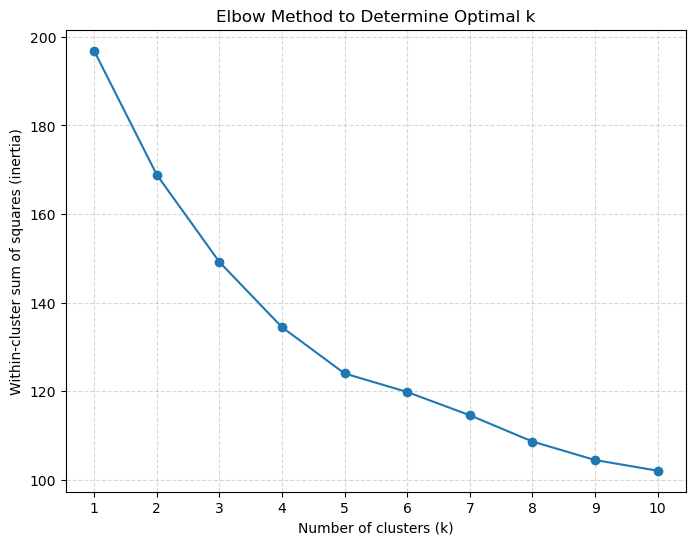

In [4]:
#determine optimal k frequency. (N.B. this will change with each run, so will look different from figure in paper)
inertia = []
k_values = range(1, 11)  # test k=1 to k=10

X = normalize(flux_df.T)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)  # sum of squared distances to cluster centers

# Plot the elbow plot
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia, marker='o')
plt.xticks(k_values)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-cluster sum of squares (inertia)')
plt.title('Elbow Method to Determine Optimal k')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


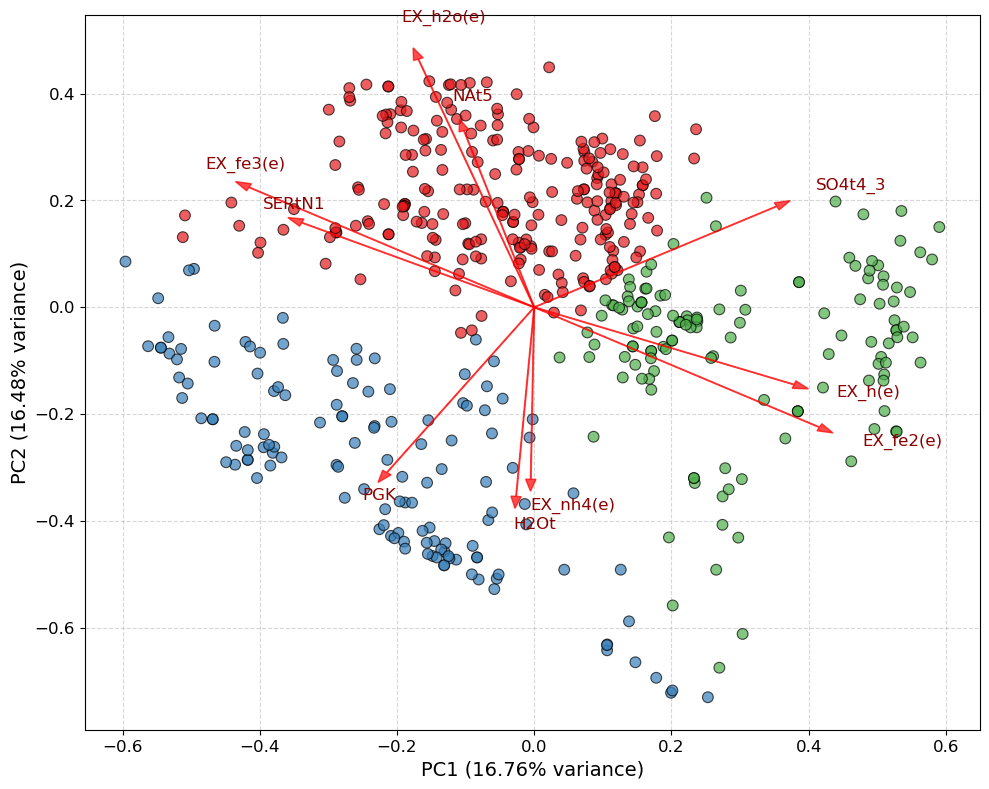

In [5]:
X = normalize(flux_df.T)  # shape: samples × features
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df_pca = pd.DataFrame(X_pca, index=flux_df.columns, columns=['PC1', 'PC2'])

#here, set k to be whatever was optimal in the elbow plot
kmeans = KMeans(n_clusters=3, random_state=1, n_init='auto')
kmeans.fit(df_pca)
cluster_labels = pd.DataFrame(kmeans.labels_, index=flux_df.columns, columns=['cluster'])
fig, ax = plt.subplots(figsize=(10, 8))

# build PCA plot
sns.scatterplot(
    data=df_pca,
    x='PC1', y='PC2',
    hue=cluster_labels['cluster'],
    palette='Set1',
    s=60,
    alpha=0.7,
    legend=False,
    edgecolor='black',   # outlines around dots
    linewidth=0.8,
    ax=ax
)

loadings = pd.DataFrame(
    pca.components_.T,  # features × PCs
    index=flux_df.index,
    columns=['PC1', 'PC2']
)

top_features = set(
    loadings['PC1'].abs().sort_values(ascending=False).head(5).index
).union(
    loadings['PC2'].abs().sort_values(ascending=False).head(5).index
)

# Plot top feature loadings as arrows
scale = 1.5  # adjust arrow length
for feature in top_features:
    x_loading = loadings.loc[feature, 'PC1'] * scale
    y_loading = loadings.loc[feature, 'PC2'] * scale
    ax.arrow(0, 0, x_loading, y_loading, color='red', alpha=0.7,
             head_width=0.015, length_includes_head=True)
    ax.text(x_loading * 1.1, y_loading * 1.1, feature, color='darkred', fontsize=12)

# Labels and grid
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)", fontsize=14, color='black')
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)", fontsize=14, color='black')
ax.tick_params(axis='both', labelsize=12, colors='black')
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# Make the outer border (spines) black
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(0.8)

plt.tight_layout()
#plt.savefig('pca_28102025_styled.png', bbox_inches='tight', dpi=300)
plt.show()

In [6]:
#how many solutions fall into each cluster?
print(cluster_labels['cluster'].value_counts())

cluster
0    234
2    133
1    133
Name: count, dtype: int64


In [7]:
#how do the loadings correlate with PC1 and PC2?
pc1_loadings = loadings['PC1'].abs().sort_values(ascending=False).head(5)
pc2_loadings = loadings['PC2'].abs().sort_values(ascending=False).head(5)
print(pc1_loadings)
print(pc2_loadings)

reaction_ids
EX_fe3(e)    0.290280
EX_fe2(e)    0.290280
EX_h(e)      0.266464
SO4t4_3      0.248815
SERtN1       0.239431
Name: PC1, dtype: float64
reaction_ids
EX_h2o(e)    0.323938
H2Ot         0.251116
NAt5         0.234758
EX_nh4(e)    0.229712
PGK          0.218708
Name: PC2, dtype: float64


### Figure 1b

In [10]:
#save cluster labels to a file, and reformat so that reactions are headers of columns and the coefficients of these reactions are the values in each column
cluster_labels.to_csv('cluster_labels_3_21102025.csv')
#import reformated file, ready to boxplot the coefficients to find trends with the Kmeans clusters
boxplot = pd.read_csv(r'boxplot_df_3_21102025.csv') #file name for reformated file (I have used the file from the data in Figure 1a in paper
boxplot = boxplot.set_index('cluster')

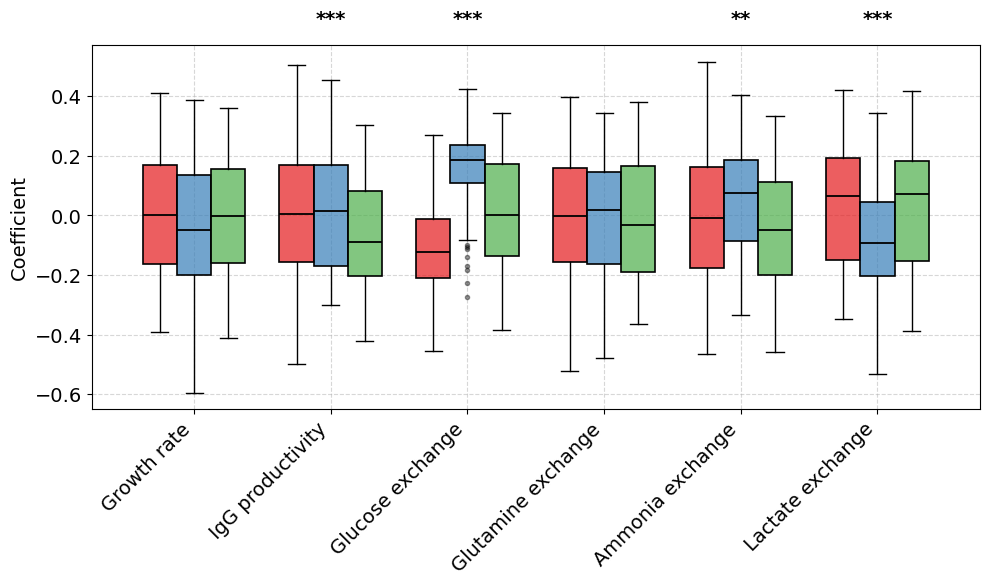

In [11]:
df = boxplot  # indexed by cluster (0, 1, 2)
clusters = sorted(df.index.unique())
reactions = df.columns

# --- Step 1: Statistical tests ---
pvals = {}
for reaction in reactions:
    groups = [df.loc[c, reaction].dropna() for c in clusters]
    if len(clusters) == 2:
        stat, p = mannwhitneyu(groups[0], groups[1], alternative='two-sided')
    else:
        stat, p = kruskal(*groups)
    pvals[reaction] = p

# --- Step 2: Plot setup ---
palette = sns.color_palette("Set1", n_colors=len(clusters))
colors = {i: (*palette[i], 0.7) for i in clusters}

fig, ax = plt.subplots(figsize=(10, 6))
positions = np.arange(len(reactions))
width = 0.25

# --- Step 3: Plot boxes ---
for i, cluster in enumerate(clusters):
    cluster_data = df.loc[cluster]
    pos = positions + (i - (len(clusters) - 1) / 2) * width
    ax.boxplot(
        [cluster_data[rxn].dropna() for rxn in reactions],
        positions=pos,
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor=colors[cluster], color='black', linewidth=1.2),
        medianprops=dict(color='black', linewidth=1.3),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        flierprops=dict(marker='o', markersize=3, markerfacecolor='black', alpha=0.4)
    )

# --- Step 4: Significance labels ---
def significance_label(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

ymax = df.max().max()
y_offset = (df.max().max() - df.min().min()) * 0.1

for i, rxn in enumerate(reactions):
    pval = pvals.get(rxn, None)
    label = significance_label(pval) if pval is not None else ''
    if label:
        ax.text(
            positions[i],
            ymax + y_offset,
            label,
            ha='center',
            va='bottom',
            fontsize=14,
            color='black',
            fontweight='bold'
        )

# --- Step 5: Labels and ticks ---
ax.set_xticks(positions)
ax.set_xticklabels(reactions, rotation=45, ha='right', fontsize=14, color='black')
ax.set_ylabel('Coefficient', fontsize=14, color='black')
ax.tick_params(axis='y', labelsize=14, colors='black')

# --- Step 6: Grid and axes styling ---
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# Set spine (plot border) colors same as tick labels
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(0.8)

plt.tight_layout()
#plt.savefig('boxplot_3clusters_matchedPCA_28102025_2_styled.png', bbox_inches='tight', dpi=300)
plt.show()

### Figure 2a-d

In [15]:
#import random objective dataframes from other time points to visualise here
%store -r stationary_flux_df_t
%store -r late_flux_df_t

#set experimental data (multiple bioreactors and then timepoints for late exponential and stationary
experimental_4 = {'growth':[0.510030396,0.604938257,0.305665659,0.354140221,0.626214894,0.481208353],
                  'igg':[0.000022675,0.0000222994,0.0000230557,0.0000228099,0.0000217354,0.0000233793],
                  'nh4':[0.058370651,0.049267192,0.058882866,0.048623245,0.057789059,0.045331473],
                  'lac':[0.198822112,0.216293484,0.261608895,0.18802327,0.193195889,0.223779804]}
experimental_678 = {'growth':[0.389603436,0.387968697,0.415823572,0.798441296,0.330042824,0.352084182,
                              0.422441519,0.417135113,0.393464278,-0.026775809,0.736742289,0.333249031,
                              0.243531691,0.167204988,0.371955397,0.339347745,-0.051891089,0.286056855],
                    'igg':[0.0000242777,0.0000245681,0.0000242784,0.0000216538,0.0000238745,0.0000242047,
                           0.0000258268,0.000026511,0.0000268954,0.0000241365,0.0000226874,0.0000260239],
                    'nh4':[-0.012978488,-0.014578577,0.007868785,0.00348815,-0.10477789,-0.013760917,
                           -0.014944994,-0.010676486,-0.014070916,-0.007595494,0.035630288,-0.010655738,
                           0.00475468,0.002951519,-0.006542142,-0.007324107,0.000612444,0.006444505],
                    'lac':[0.07078951,0.052416301,0.093596572,0.09241039,0.102084868,0.094567197,
                          -0.056561822,-0.04591698,0.007007069,-0.021080702,-0.029915255,-0.035527413,
                           -0.096203392,-0.093553083,-0.101896217,-0.097832833,-0.097931067,-0.110433878]}
experimental_111214 = {'growth':[0.179825488,0.016026168,-0.018670135,0.038544934,-0.012699689,0.02494489,
                                 -0.258307167,-0.029822899,-0.007294113,0.008807656,-0.072776522,-0.188476755,
                                 -0.090650096,-0.033949435,-0.057667365,-0.114462047,-0.01782574,0.016909876],
                       'igg':[0.0000248848,0.000025026,0.0000268595,0.0000269257,0.0000234689,0.0000268045,
                              0.0000235376,0.0000243795,0.000027795,0.0000263168,0.000022754,0.0000269515],
                       'nh4':[-0.012978488,-0.014578577,0.007868785,0.00348815,-0.10477789,-0.013760917,
                              -0.014944994,-0.010676486,-0.014070916,-0.007595494,0.035630288,-0.010655738,
                              0.00475468,0.002951519,-0.006542142,-0.007324107,0.000612444,0.006444505],
                       'lac':[0.07078951,0.052416301,0.093596572,0.09241039,0.102084868,0.094567197,
                              -0.056561822,-0.04591698,0.007007069,-0.021080702,-0.029915255,-0.035527413,
                             -0.096203392,-0.093553083,-0.101896217,-0.097832833,-0.097931067,-0.110433878]}
#set model predictions across random samples
growth_predictions_early = flux_df_t['biomass_cho_prod'].to_list()
igg_predictions_early = flux_df_t['ICproduct_TRANSLATION_protein'].to_list()
nh4_predictions_early = flux_df_t['EX_nh4(e)'].to_list()
lac_predictions_early = flux_df_t['EX_lac_L(e)'].to_list()
growth_predictions_late = late_flux_df_t['biomass_cho_prod'].to_list()
igg_predictions_late = late_flux_df_t['ICproduct_TRANSLATION_protein'].to_list()
nh4_predictions_late = late_flux_df_t['EX_nh4(e)'].to_list()
lac_predictions_late = late_flux_df_t['EX_lac_L(e)'].to_list()
growth_predictions_stationary = stationary_flux_df_t['biomass_cho_prod'].to_list()
igg_predictions_stationary = stationary_flux_df_t['ICproduct_TRANSLATION_protein'].to_list()
nh4_predictions_stationary = stationary_flux_df_t['EX_nh4(e)'].to_list()
lac_predictions_stationary = stationary_flux_df_t['EX_lac_L(e)'].to_list()

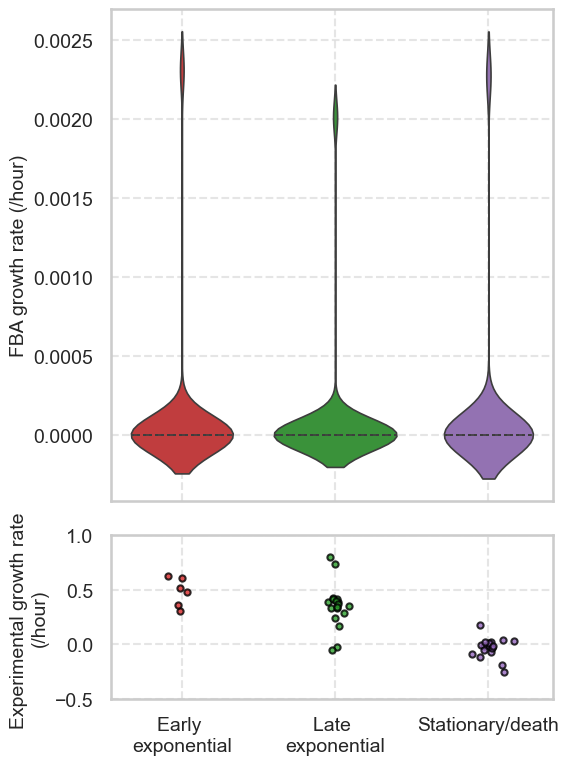

In [16]:
growth_data = {
    'Phase': (['Early'] * len(growth_predictions_early)) +
             (['Late'] * len(growth_predictions_late)) +
             (['Stationary'] * len(growth_predictions_stationary)),
    'Growth': growth_predictions_early + growth_predictions_late + growth_predictions_stationary
}

df_growth = pd.DataFrame(growth_data)

# --- Experimental replicate data ---
exp_data_list = [experimental_4['growth'], experimental_678['growth'], experimental_111214['growth']]

# --- Settings ---
sns.set(style='whitegrid', context='talk')
custom_palette = ['#d62728', '#2ca02c', '#9467bd']  # red, green, purple
phase_order = ['Early', 'Late', 'Stationary']

# --- Create subplots ---
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(6, 8),
    gridspec_kw={'height_ratios': [3, 1]},
    sharex=True
)

# --- Top panel: Violin plot (predictions) ---
sns.violinplot(
    data=df_growth,
    x='Phase',
    y='Growth',
    palette=custom_palette,
    inner='quartile',
    linewidth=1.2,
    alpha=0.85,
    order=phase_order,
    ax=ax1
)

# --- Bottom panel: Scatter plot of experimental replicates ---
for i, (points, color) in enumerate(zip(exp_data_list, custom_palette)):
    x_jitter = np.random.normal(i, 0.05, size=len(points))  # add horizontal jitter
    ax2.scatter(x_jitter, points, color=color, edgecolor='black', s=20, alpha=0.8)

# --- Axis labels & styling ---
ax1.set_xlabel('')
ax1.set_ylabel('FBA growth rate (/hour)', fontsize=14)
ax2.set_ylabel('Experimental growth rate \n(/hour)', fontsize=14)
ax2.set_xticks(range(len(phase_order)))
ax2.set_xticklabels(['Early \nexponential','Late \nexponential','Stationary/death'], fontsize=14)
ax2.set_ylim(-0.5, 1.0) 

for ax in [ax1, ax2]:
    ax.tick_params(labelsize=14)
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

plt.tight_layout()
#plt.savefig('growth_comparison_23102025.png',bbox_inches='tight',dpi=300)
plt.show()

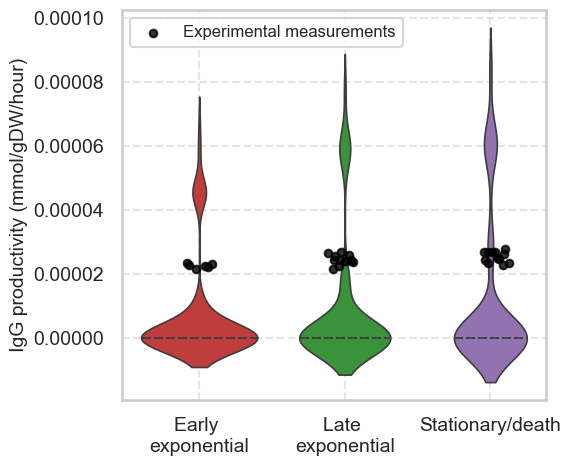

In [17]:
# --- Combine prediction data ---
igg_data = {
    'Phase': (['Early'] * len(igg_predictions_early)) +
             (['Late'] * len(igg_predictions_late)) +
             (['Stationary'] * len(igg_predictions_stationary)),
    'IgG productivity': igg_predictions_early + igg_predictions_late + igg_predictions_stationary
}
df_igg = pd.DataFrame(igg_data)

# --- Experimental replicate data ---
exp_data_list = [experimental_4['igg'], experimental_678['igg'], experimental_111214['igg']]

# --- Settings ---
sns.set(style='whitegrid', context='talk')
custom_palette = ['#d62728', '#2ca02c', '#9467bd']  # red, green, purple
phase_order = ['Early', 'Late', 'Stationary']

# --- Create figure ---
plt.figure(figsize=(6, 5))

# Violin plot (predictions)
sns.violinplot(
    data=df_igg,
    x='Phase',
    y='IgG productivity',
    palette=custom_palette,  # keep colored violins
    inner='quartile',
    linewidth=1.2,
    alpha=0.85,
    order=phase_order
)

# Overlay experimental points in black
for i, points in enumerate(exp_data_list):
    x_jitter = np.random.normal(i, 0.05, size=len(points))  # horizontal jitter
    plt.scatter(x_jitter, points, color='black', s=30, alpha=0.8, zorder=5, label='Experimental measurements' if i==0 else "")

# Formatting
plt.xlabel('')
phase_labels = ['Early \nexponential', 'Late \nexponential', 'Stationary/death']
plt.xticks(ticks=range(len(phase_order)), labels=phase_labels, fontsize=14)
plt.ylabel('IgG productivity (mmol/gDW/hour)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5, zorder=0)

# Add legend (only one entry for all experimental points)
plt.legend(fontsize=12)

plt.tight_layout()
#plt.savefig('igg_comparison_23102025.png',bbox_inches='tight',dpi=300)
plt.show()

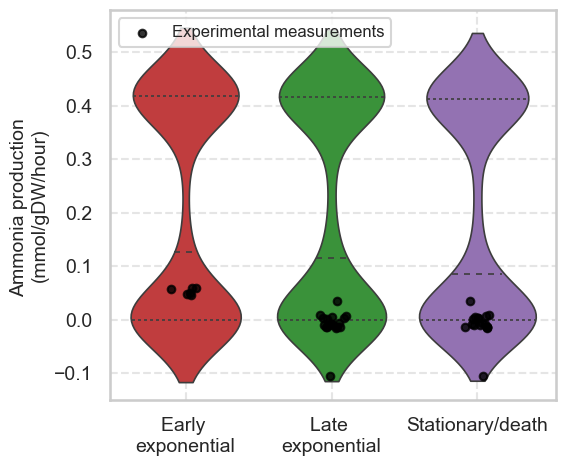

In [18]:
# --- Combine prediction data ---
nh4_data = {
    'Phase': (['Early'] * len(nh4_predictions_early)) +
             (['Late'] * len(nh4_predictions_late)) +
             (['Stationary'] * len(nh4_predictions_stationary)),
    'Ammonia production': nh4_predictions_early + nh4_predictions_late + nh4_predictions_stationary
}
df_nh4 = pd.DataFrame(nh4_data)

# --- Experimental replicate data ---
exp_data_list = [experimental_4['nh4'], experimental_678['nh4'], experimental_111214['nh4']]

# --- Settings ---
sns.set(style='whitegrid', context='talk')
custom_palette = ['#d62728', '#2ca02c', '#9467bd']  # red, green, purple
phase_order = ['Early', 'Late', 'Stationary']

# --- Create figure ---
plt.figure(figsize=(6, 5))

# Violin plot (predictions)
sns.violinplot(
    data=df_nh4,
    x='Phase',
    y='Ammonia production',
    palette=custom_palette,  # keep colored violins
    inner='quartile',
    linewidth=1.2,
    alpha=0.85,
    order=phase_order
)

# Overlay experimental points in black
for i, points in enumerate(exp_data_list):
    x_jitter = np.random.normal(i, 0.05, size=len(points))  # horizontal jitter
    plt.scatter(x_jitter, points, color='black', s=30, alpha=0.8, zorder=5, label='Experimental measurements' if i==0 else "")

# Formatting
plt.xlabel('')
phase_labels = ['Early \nexponential', 'Late \nexponential', 'Stationary/death']
plt.xticks(ticks=range(len(phase_order)), labels=phase_labels, fontsize=14)
plt.ylabel('Ammonia production \n(mmol/gDW/hour)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5, zorder=0)

# Add legend (only one entry for all experimental points)
plt.legend(fontsize=12,loc='upper left')

plt.tight_layout()
#plt.savefig('nh4_comparison_23102025.png',bbox_inches='tight',dpi=300)
plt.show()

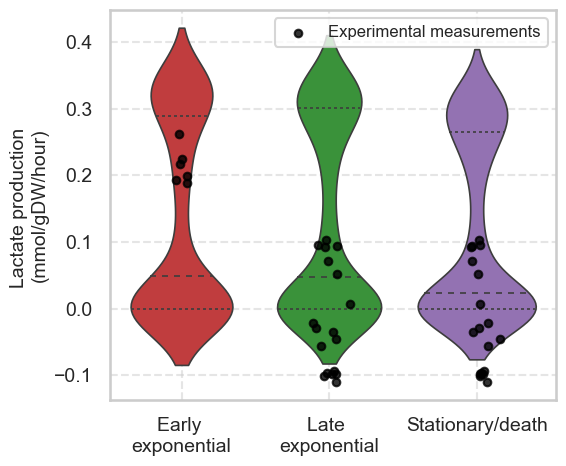

In [19]:
# --- Combine prediction data ---
lac_data = {
    'Phase': (['Early'] * len(lac_predictions_early)) +
             (['Late'] * len(lac_predictions_late)) +
             (['Stationary'] * len(lac_predictions_stationary)),
    'Lactate production': lac_predictions_early + lac_predictions_late + lac_predictions_stationary
}
df_lac = pd.DataFrame(lac_data)

# --- Experimental replicate data ---
exp_data_list = [experimental_4['lac'], experimental_678['lac'], experimental_111214['lac']]

# --- Settings ---
sns.set(style='whitegrid', context='talk')
custom_palette = ['#d62728', '#2ca02c', '#9467bd']  # red, green, purple
phase_order = ['Early', 'Late', 'Stationary']

# --- Create figure ---
plt.figure(figsize=(6, 5))

# Violin plot (predictions)
sns.violinplot(
    data=df_lac,
    x='Phase',
    y='Lactate production',
    palette=custom_palette,  # keep colored violins
    inner='quartile',
    linewidth=1.2,
    alpha=0.85,
    order=phase_order
)

# Overlay experimental points in black
for i, points in enumerate(exp_data_list):
    x_jitter = np.random.normal(i, 0.05, size=len(points))  # horizontal jitter
    plt.scatter(x_jitter, points, color='black', s=30, alpha=0.8, zorder=5, label='Experimental measurements' if i==0 else "")

# Formatting
plt.xlabel('')
phase_labels = ['Early \nexponential', 'Late \nexponential', 'Stationary/death']
plt.xticks(ticks=range(len(phase_order)), labels=phase_labels, fontsize=14)
plt.ylabel('Lactate production \n(mmol/gDW/hour)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5, zorder=0)

# Add legend (only one entry for all experimental points)
plt.legend(fontsize=12,loc='upper right')

plt.tight_layout()
#plt.savefig('lac_comparison_23102025.png',bbox_inches='tight',dpi=300)
plt.show()

### Figure 2e

In [12]:
criteria = {
    "ICproduct_TRANSLATION_protein": 1,   # IgG secretion (positive flux)
    "biomass_cho_prod": 1,   # Biomass production - i.e. cells are growing (positive flux)
    "EX_nh4(e)": 1,  # Ammonia secretion (positive flux)
    "EX_lac_L(e)": 1   # Lactate secretion (positive flux)
}

flux_df_t = flux_df.transpose() #transpose df so can search through for biostat reactions

scores_tally = []
for n in range(len(flux_df_t)):
    score = 0
    growth_flux = float(flux_df_t['biomass_cho_prod'][n])
    if growth_flux > 0:
        growth_flux_rounded = 1
    if growth_flux < 0:
        growth_flux_rounded = -1
    if growth_flux ==0:
        growth_flux_rounded = 0
    if growth_flux_rounded == criteria['biomass_cho_prod']:
        score = score+1
    
    igg_flux = float(flux_df_t['ICproduct_TRANSLATION_protein'][n])
    if igg_flux > 0:
        igg_flux_rounded = 1
    if igg_flux < 0:
        igg_flux_rounded = -1
    if igg_flux ==0:
        igg_flux_rounded = 0
    if igg_flux_rounded == criteria['ICproduct_TRANSLATION_protein']:
        score = score+1

    ammonia_flux = float(flux_df_t['EX_nh4(e)'][n])
    if ammonia_flux > 0:
        ammonia_flux_rounded = 1
    if ammonia_flux < 0:
        ammonia_flux_rounded = -1
    if ammonia_flux ==0:
        ammonia_flux_rounded = 0
    if ammonia_flux_rounded == criteria['EX_nh4(e)']:
        score = score+1

    lactate_flux = float(flux_df_t['EX_lac_L(e)'][n])
    if lactate_flux > 0:
        lactate_flux_rounded = 1
    if lactate_flux < 0:
        lactate_flux_rounded = -1
    if lactate_flux ==0:
        lactate_flux_rounded = 0
    if lactate_flux_rounded == criteria['EX_lac_L(e)']:
        score = score+1

    scores_tally.append(score)

print('proportion of samples that reached 100% accuracy:',scores_tally.count(4))
print('proportion of samples that reached 75% accuracy:',scores_tally.count(3))
print('proportion of samples that reached 50% accuracy:',scores_tally.count(2))
print('proportion of samples that reached 25% accuracy:',scores_tally.count(1))
print('proportion of samples that reached 0% accuracy:',scores_tally.count(0))

proportion of samples that reached 100% accuracy: 0
proportion of samples that reached 75% accuracy: 3
proportion of samples that reached 50% accuracy: 223
proportion of samples that reached 25% accuracy: 218
proportion of samples that reached 0% accuracy: 56


C:\Users\p04121km\AppData\Local\Temp\ipykernel_13316\2823111385.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  growth_flux = float(flux_df_t['biomass_cho_prod'][n])
C:\Users\p04121km\AppData\Local\Temp\ipykernel_13316\2823111385.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  igg_flux = float(flux_df_t['ICproduct_TRANSLATION_protein'][n])
C:\Users\p04121km\AppData\Local\Temp\ipykernel_13316\2823111385.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by

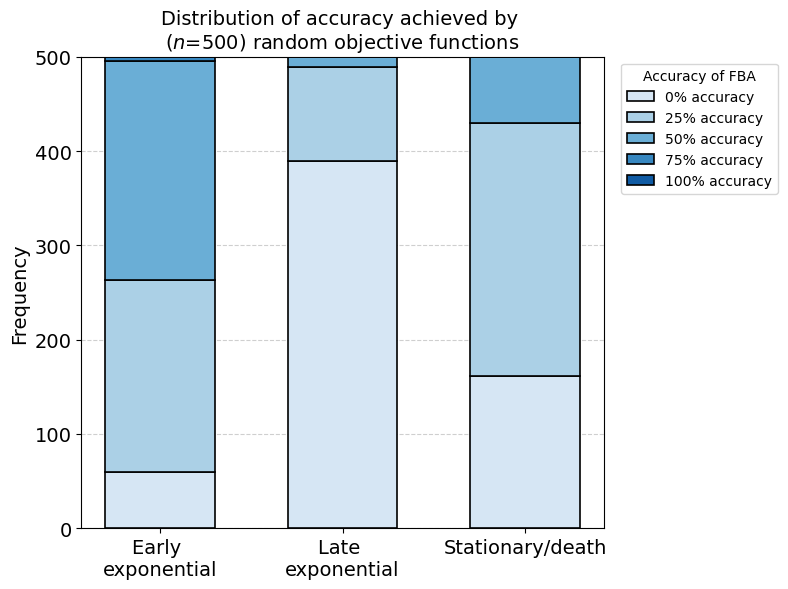

In [14]:
phases = ('Early \nexponential', 'Late \nexponential', 'Stationary/death')
#manually write frequencies from each accuracy category (these are the ones from the simulation that was shown in the paper)
#this requires creating a random objective flux_df for the other culture phases and also filling these values in here
accuracy_frequencies = {
    '0% accuracy': (60, 389, 161),
    '25% accuracy': (203, 100, 269),
    '50% accuracy': (232, 11, 70),
    '75% accuracy': (5, 0, 0),
    '100% accuracy': (0, 0, 0)
}

# --- Create DataFrame ---
df = pd.DataFrame(accuracy_frequencies, index=phases)

# --- Color palette (Set1) ---
palette = sns.color_palette("Blues", n_colors=len(df.columns))

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))

bottom = np.zeros(len(df))
for (accuracy, values), color in zip(df.items(), palette):
    ax.bar(
        df.index,
        values,
        bottom=bottom,
        label=accuracy,
        color=color,
        edgecolor='black',
        linewidth=1.2,
        zorder=3,
        width=0.6
    )
    bottom += values

# --- Formatting ---
ax.set_ylabel('Frequency', fontsize=14)
ax.set_title('Distribution of accuracy achieved by \n($n$=500) random objective functions', fontsize=14)
ax.tick_params(axis='both', labelsize=14)
ax.legend(
    fontsize=10,
    title='Accuracy of FBA',
    loc='upper left',             # starting reference point
    bbox_to_anchor=(1.02, 1)      # move it outside to the right
)
ax.grid(True, axis='y', linestyle='--', alpha=0.6, zorder=0)

plt.tight_layout()
#plt.savefig('accuracies_22102025.png', bbox_inches='tight', dpi=300)
plt.show()